<a href="https://colab.research.google.com/github/Damainx22/RGV-Business-Survival/blob/main/notebooks/06_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ============================================
# Notebook 06: Exploratory Data Analysis (EDA)
# Purpose: Visualize patterns in the merged dataset
#          to understand what drives business loan
#          defaults in Texas, with focus on the RGV.
#          These visualizations will be used in the
#          proposal presentation.
# ============================================

# Mount Google Drive so we can access our merged dataset
from google.colab import drive
drive.mount('/content/drive')

# Standard imports
import os
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt  # base plotting library
import seaborn as sns             # statistical visualizations
import plotly.express as px       # interactive charts and maps

# Define folder paths
RAW = '/content/drive/MyDrive/rgv_business_survival/data/raw'
CLEANED = '/content/drive/MyDrive/rgv_business_survival/data/cleaned'
MERGED = '/content/drive/MyDrive/rgv_business_survival/data/merged'

# Load the merged master dataset created in notebook 05
model_df = pd.read_csv(f'{MERGED}/model_df.csv')

# Verify it loaded correctly
print(f'Rows: {len(model_df)}, Columns: {len(model_df.columns)}')
print(model_df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Rows: 8064, Columns: 22
                   borrname  borrcity  borrzip  grossapproval  \
0  Elite Sprinkler Services      KATY    77450          15000   
1                Tax2Go LLC    Desoto    75115         125000   
2   Upstairs Circus Atx LLC    Austin    78701         455000   
3    BARGE INVESTMENTS INC.  LONGVIEW    75605         200000   
4                  PP9A LLC   BAYTOWN    77523          40000   

   sbaguaranteedapproval  approvalfiscalyear  initialinterestrate  \
0                 7500.0                2018                10.00   
1               106250.0                2018                 7.25   
2               341250.0                2018                 6.50   
3               150000.0                2018                 7.25   
4                20000.0                2018                 7.85   

   terminmonths  naicscode               

/tmp/ipykernel_7809/42749588.py:18: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




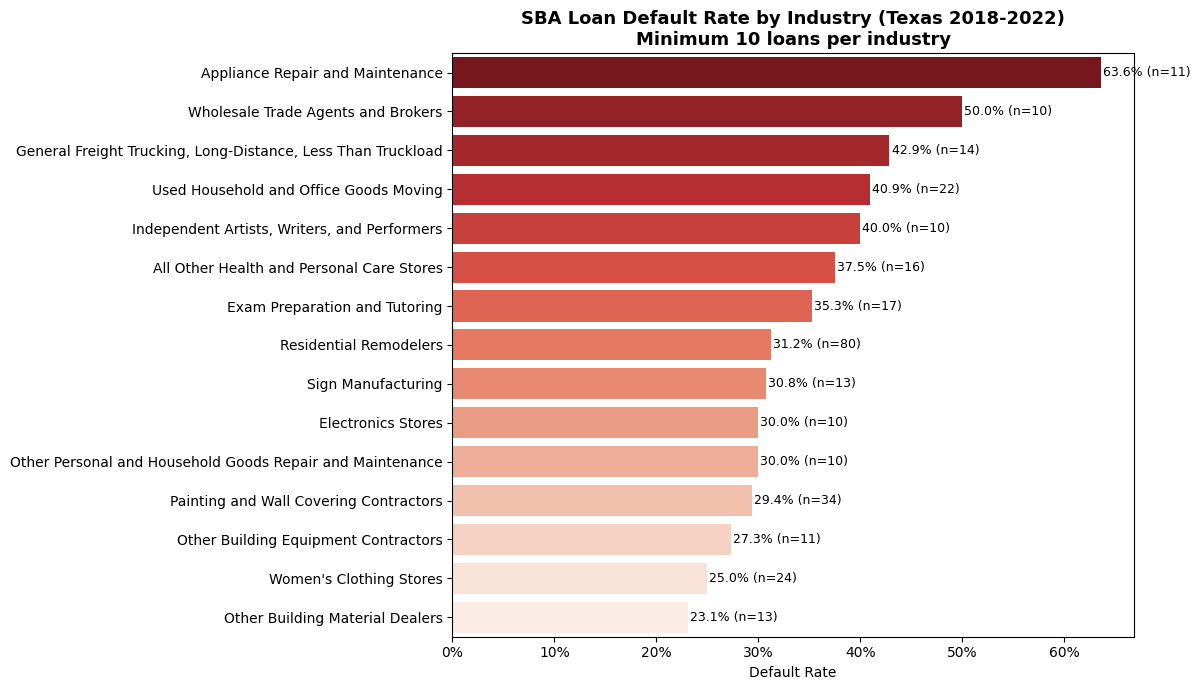

                                                 naicsdescription  total_loans  default_rate
54                               Appliance Repair and Maintenance           11      0.636364
572                            Wholesale Trade Agents and Brokers           10      0.500000
221  General Freight Trucking, Long-Distance, Less Than Truckload           14      0.428571
564                        Used Household and Office Goods Moving           22      0.409091
251                  Independent Artists, Writers, and Performers           10      0.400000
12                      All Other Health and Personal Care Stores           16      0.375000
181                                 Exam Preparation and Tutoring           17      0.352941
480                                        Residential Remodelers           80      0.312500
504                                            Sign Manufacturing           13      0.307692
175                                            Electronics Stores     

In [6]:
# ============================================
# Cell 2: Default Rate by Industry (Top 15)
# Answers: Which industries fail most in Texas?
# ============================================

# Calculate default rate per industry
# Only include industries with at least 10 loans for statistical reliability
industry_default = (model_df.groupby('naicsdescription')
                    .agg(total_loans=('defaulted', 'count'),
                         default_rate=('defaulted', 'mean'))
                    .reset_index()
                    .query('total_loans >= 10')
                    .sort_values('default_rate', ascending=False)
                    .head(15))

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=industry_default, x='default_rate', y='naicsdescription',
            palette='Reds_r', ax=ax)

# Add percentage labels on bars
for i, (rate, total) in enumerate(zip(industry_default['default_rate'],
                                       industry_default['total_loans'])):
    ax.text(rate + 0.002, i, f'{rate*100:.1f}% (n={total})',
            va='center', fontsize=9)

ax.set_title('SBA Loan Default Rate by Industry (Texas 2018-2022)\nMinimum 10 loans per industry',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Default Rate')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/rgv_business_survival/charts/01_default_by_industry.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(industry_default[['naicsdescription', 'total_loans', 'default_rate']].to_string())

/tmp/ipykernel_7809/2916754994.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




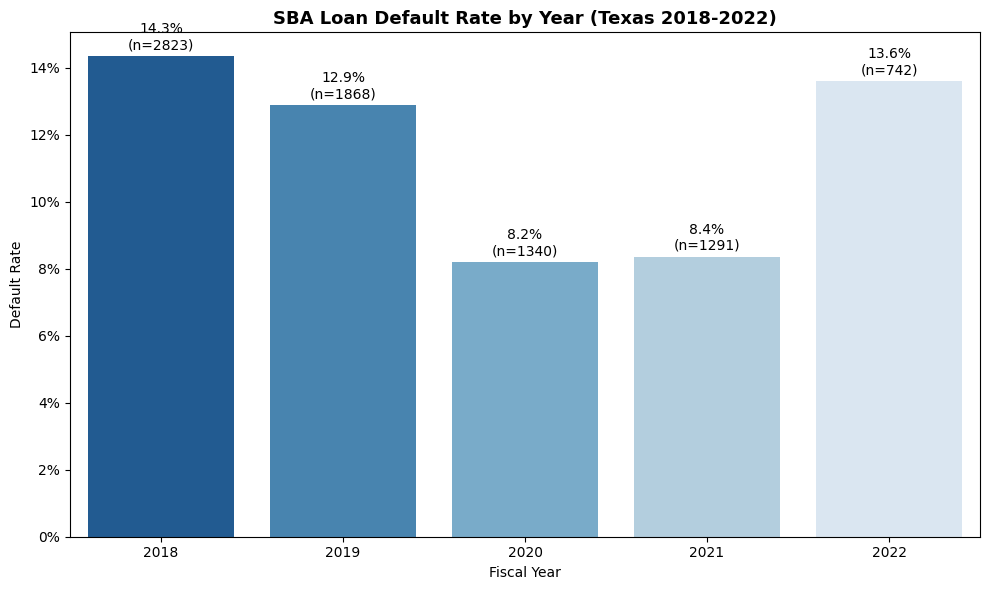

   approvalfiscalyear  total_loans  default_rate
0                2018         2823      0.143464
1                2019         1868      0.129015
2                2020         1340      0.082090
3                2021         1291      0.083656
4                2022          742      0.136119


In [7]:
# ============================================
# Cell 3: Default Rate by Year (2018-2022)
# Answers: How did COVID affect default rates?
# ============================================

year_default = (model_df.groupby('approvalfiscalyear')
                .agg(total_loans=('defaulted', 'count'),
                     default_rate=('defaulted', 'mean'))
                .reset_index())

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=year_default, x='approvalfiscalyear', y='default_rate',
            palette='Blues_r', ax=ax)

for i, (rate, total) in enumerate(zip(year_default['default_rate'],
                                       year_default['total_loans'])):
    ax.text(i, rate + 0.002, f'{rate*100:.1f}%\n(n={total})',
            ha='center', fontsize=10)

ax.set_title('SBA Loan Default Rate by Year (Texas 2018-2022)', fontsize=13, fontweight='bold')
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Default Rate')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/rgv_business_survival/charts/02_default_by_year.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(year_default)

/tmp/ipykernel_7809/443218781.py:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_7809/443218781.py:14: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



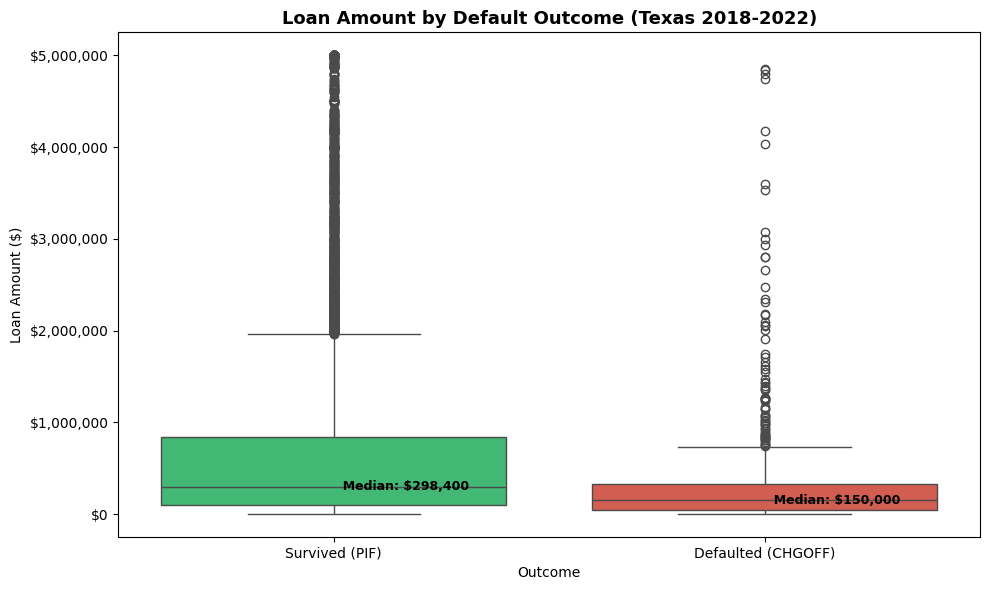

Median loan - Survived: 298400.0
Median loan - Defaulted: 150000.0


In [8]:
# ============================================
# Cell 4: Loan Amount vs Default Outcome
# Answers: Do smaller loans default more?
# ============================================

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=model_df, x='defaulted', y='grossapproval',
            palette=['#2ecc71', '#e74c3c'], ax=ax)

ax.set_title('Loan Amount by Default Outcome (Texas 2018-2022)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Outcome')
ax.set_ylabel('Loan Amount ($)')
ax.set_xticklabels(['Survived (PIF)', 'Defaulted (CHGOFF)'])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Add median labels
for i, outcome in enumerate([0, 1]):
    median = model_df[model_df['defaulted'] == outcome]['grossapproval'].median()
    ax.text(i, median, f'  Median: ${median:,.0f}',
            va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/rgv_business_survival/charts/03_loan_amount_vs_default.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Median loan - Survived:", model_df[model_df['defaulted']==0]['grossapproval'].median())
print("Median loan - Defaulted:", model_df[model_df['defaulted']==1]['grossapproval'].median())

/tmp/ipykernel_7809/1575205024.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




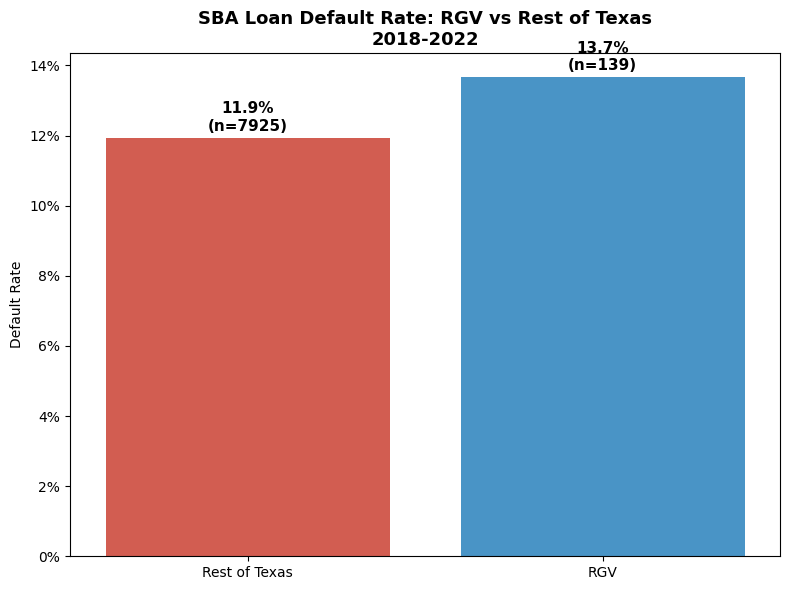

          region  total_loans  default_rate
0  Rest of Texas         7925      0.119369
1            RGV          139      0.136691


In [9]:
# ============================================
# Cell 5: RGV vs Rest of Texas Default Rate
# Answers: How does the Valley compare to Texas?
# ============================================

# Create RGV flag — zip codes starting with 785
model_df['is_rgv'] = model_df['borrzip'].astype(str).str.startswith('785')

rgv_comparison = (model_df.groupby('is_rgv')
                  .agg(total_loans=('defaulted', 'count'),
                       default_rate=('defaulted', 'mean'))
                  .reset_index())
rgv_comparison['region'] = rgv_comparison['is_rgv'].map({True: 'RGV', False: 'Rest of Texas'})

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=rgv_comparison, x='region', y='default_rate',
            palette=['#e74c3c', '#3498db'], ax=ax)

for i, (rate, total) in enumerate(zip(rgv_comparison['default_rate'],
                                       rgv_comparison['total_loans'])):
    ax.text(i, rate + 0.002, f'{rate*100:.1f}%\n(n={total})',
            ha='center', fontsize=11, fontweight='bold')

ax.set_title('SBA Loan Default Rate: RGV vs Rest of Texas\n2018-2022',
             fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Default Rate')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/rgv_business_survival/charts/04_rgv_vs_texas.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(rgv_comparison[['region', 'total_loans', 'default_rate']])

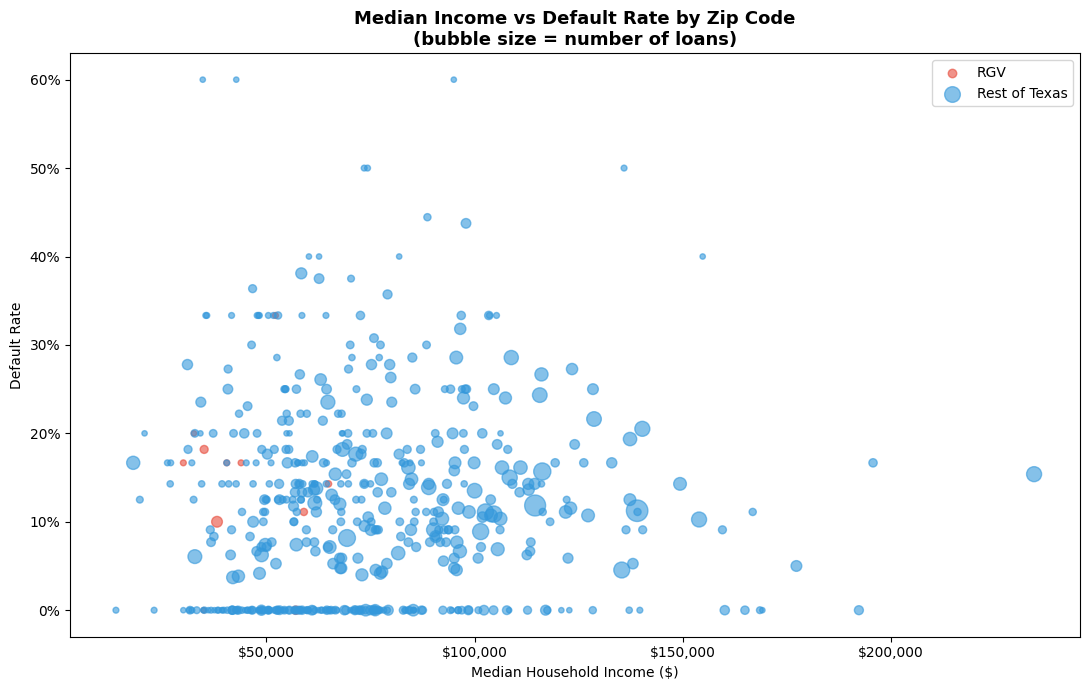

In [10]:
# ============================================
# Cell 6: Income vs Default Rate by Zip Code
# Answers: Do wealthier zip codes have lower default rates?
# ============================================

zip_stats = (model_df.groupby('borrzip')
             .agg(default_rate=('defaulted', 'mean'),
                  total_loans=('defaulted', 'count'),
                  median_income=('median_income', 'mean'),
                  poverty_rate=('poverty_rate', 'mean'))
             .reset_index()
             .query('total_loans >= 5'))

# Color by RGV vs Texas
zip_stats['region'] = zip_stats['borrzip'].astype(str).str.startswith('785').map({True: 'RGV', False: 'Rest of Texas'})

fig, ax = plt.subplots(figsize=(11, 7))
for region, color in [('RGV', '#e74c3c'), ('Rest of Texas', '#3498db')]:
    subset = zip_stats[zip_stats['region'] == region]
    ax.scatter(subset['median_income'], subset['default_rate'],
               s=subset['total_loans'] * 3, alpha=0.6,
               color=color, label=region)

ax.set_title('Median Income vs Default Rate by Zip Code\n(bubble size = number of loans)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Median Household Income ($)')
ax.set_ylabel('Default Rate')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/rgv_business_survival/charts/05_income_vs_default.png',
            dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_7809/2907499975.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




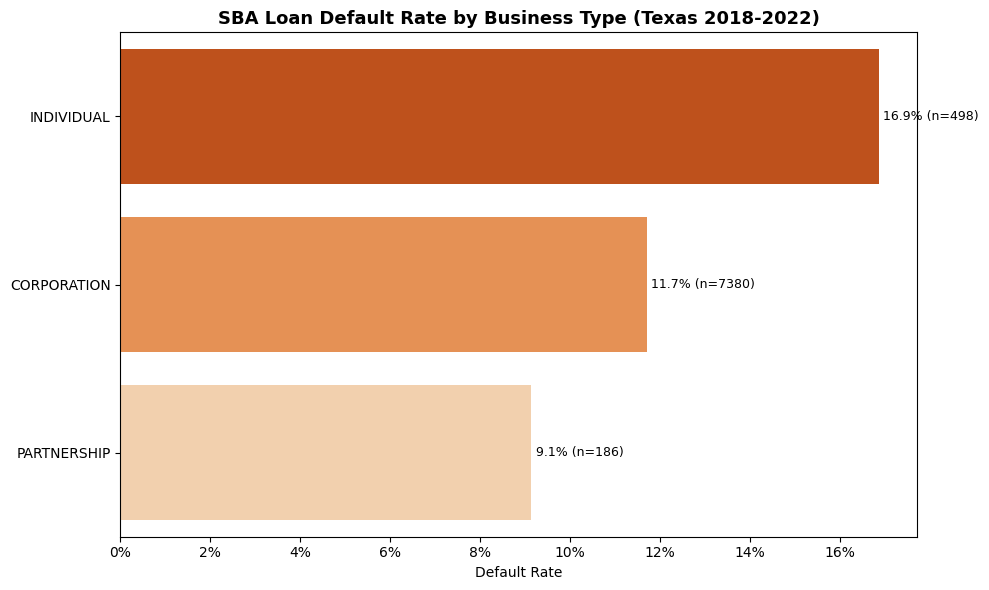

  businesstype  total_loans  default_rate
1   INDIVIDUAL          498      0.168675
0  CORPORATION         7380      0.117073
2  PARTNERSHIP          186      0.091398


In [11]:
# ============================================
# Cell 7: Default Rate by Business Type
# Answers: Do corporations survive better than individuals?
# ============================================

btype_default = (model_df.groupby('businesstype')
                 .agg(total_loans=('defaulted', 'count'),
                      default_rate=('defaulted', 'mean'))
                 .reset_index()
                 .query('total_loans >= 10')
                 .sort_values('default_rate', ascending=False))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=btype_default, x='default_rate', y='businesstype',
            palette='Oranges_r', ax=ax)

for i, (rate, total) in enumerate(zip(btype_default['default_rate'],
                                       btype_default['total_loans'])):
    ax.text(rate + 0.001, i, f'{rate*100:.1f}% (n={total})',
            va='center', fontsize=9)

ax.set_title('SBA Loan Default Rate by Business Type (Texas 2018-2022)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Default Rate')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/rgv_business_survival/charts/06_default_by_business_type.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(btype_default[['businesstype', 'total_loans', 'default_rate']].to_string())

/tmp/ipykernel_7809/1442135468.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




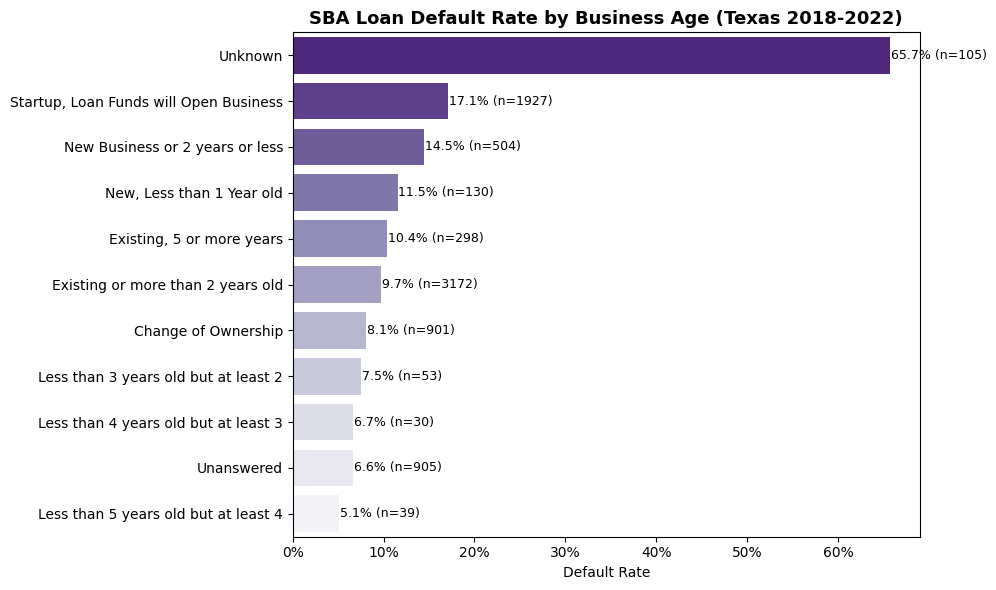

                               businessage  total_loans  default_rate
10                                 Unknown          105      0.657143
8   Startup, Loan Funds will Open Business         1927      0.170732
6          New Business or 2 years or less          504      0.144841
7                New, Less than 1 Year old          130      0.115385
2                Existing, 5 or more years          298      0.104027
1        Existing or more than 2 years old         3172      0.096784
0                      Change of Ownership          901      0.081021
3     Less than 3 years old but at least 2           53      0.075472
4     Less than 4 years old but at least 3           30      0.066667
9                               Unanswered          905      0.066298
5     Less than 5 years old but at least 4           39      0.051282


In [12]:
# ============================================
# Cell 8: Default Rate by Business Age
# Answers: Do startups fail more than existing businesses?
# ============================================

age_default = (model_df.groupby('businessage')
               .agg(total_loans=('defaulted', 'count'),
                    default_rate=('defaulted', 'mean'))
               .reset_index()
               .query('total_loans >= 10')
               .sort_values('default_rate', ascending=False))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=age_default, x='default_rate', y='businessage',
            palette='Purples_r', ax=ax)

for i, (rate, total) in enumerate(zip(age_default['default_rate'],
                                       age_default['total_loans'])):
    ax.text(rate + 0.001, i, f'{rate*100:.1f}% (n={total})',
            va='center', fontsize=9)

ax.set_title('SBA Loan Default Rate by Business Age (Texas 2018-2022)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Default Rate')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/rgv_business_survival/charts/07_default_by_business_age.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(age_default[['businessage', 'total_loans', 'default_rate']].to_string())

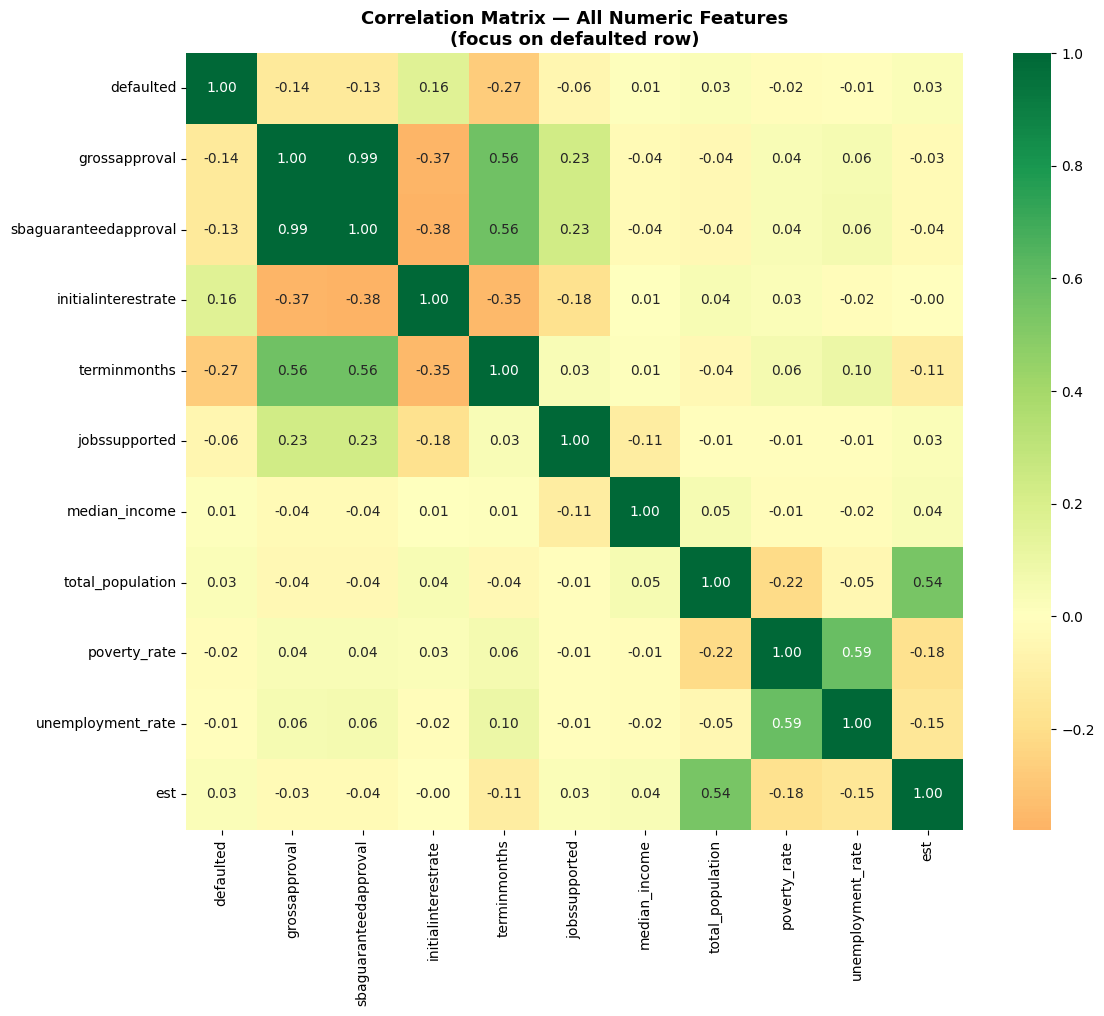

Correlation with default:
terminmonths            -0.271430
grossapproval           -0.136365
sbaguaranteedapproval   -0.134815
jobssupported           -0.056170
poverty_rate            -0.018720
unemployment_rate       -0.010175
median_income            0.011649
total_population         0.027846
est                      0.029394
initialinterestrate      0.159262
defaulted                1.000000
Name: defaulted, dtype: float64


In [13]:
# ============================================
# Cell 9: Correlation Heatmap
# Answers: Which numeric features correlate with default?
# ============================================

# Select numeric columns for correlation
numeric_cols = ['defaulted', 'grossapproval', 'sbaguaranteedapproval',
                'initialinterestrate', 'terminmonths', 'jobssupported',
                'median_income', 'total_population', 'poverty_rate',
                'unemployment_rate', 'est']

corr_matrix = model_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, square=True)

ax.set_title('Correlation Matrix — All Numeric Features\n(focus on defaulted row)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/rgv_business_survival/charts/08_correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print correlation with defaulted specifically
print("Correlation with default:")
print(corr_matrix['defaulted'].sort_values())

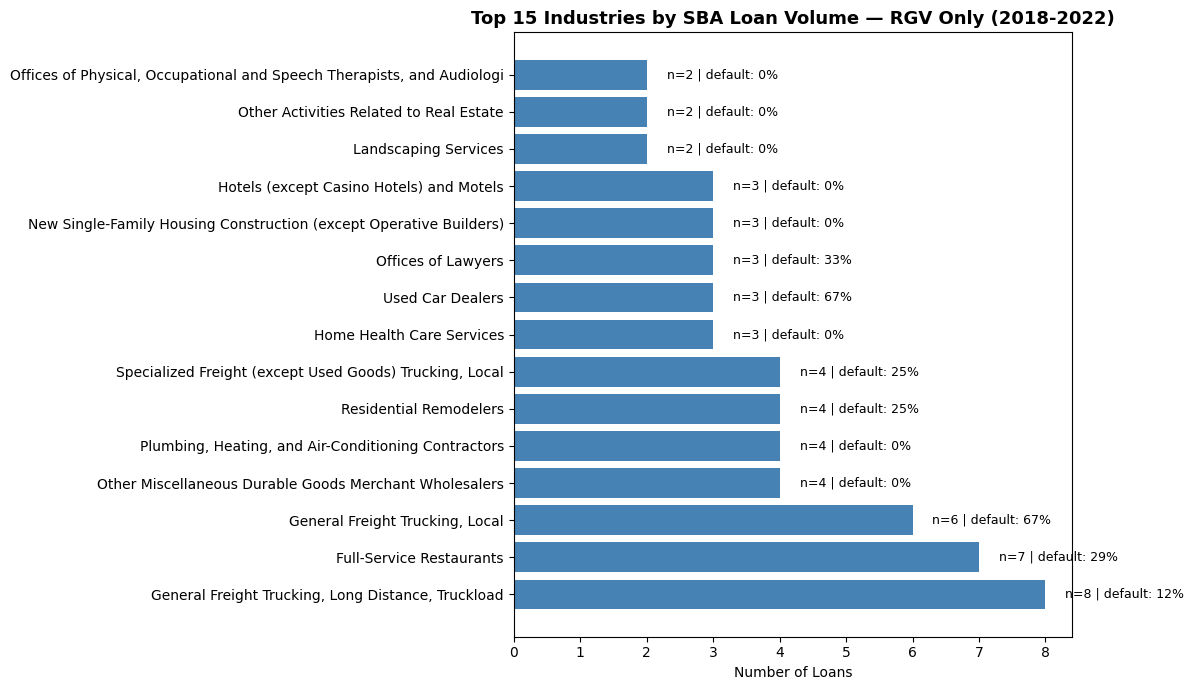

                                                          naicsdescription  total_loans  default_rate
29                      General Freight Trucking, Long Distance, Truckload            8      0.125000
26                                                Full-Service Restaurants            7      0.285714
28                                         General Freight Trucking, Local            6      0.666667
59                  Other Miscellaneous Durable Goods Merchant Wholesalers            4      0.000000
68                     Plumbing, Heating, and Air-Conditioning Contractors            4      0.000000
70                                                  Residential Remodelers            4      0.250000
73                 Specialized Freight (except Used Goods) Trucking, Local            4      0.250000
32                                               Home Health Care Services            3      0.000000
84                                                        Used Car Dealers        

In [14]:
# ============================================
# Cell 10: Top Industries in RGV
# Answers: What types of businesses get SBA loans in the Valley?
# ============================================

rgv_industries = (model_df[model_df['borrzip'].astype(str).str.startswith('785')]
                  .groupby('naicsdescription')
                  .agg(total_loans=('defaulted', 'count'),
                       default_rate=('defaulted', 'mean'))
                  .reset_index()
                  .sort_values('total_loans', ascending=False)
                  .head(15))

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(rgv_industries['naicsdescription'],
               rgv_industries['total_loans'],
               color='steelblue')

for i, (total, rate) in enumerate(zip(rgv_industries['total_loans'],
                                       rgv_industries['default_rate'])):
    ax.text(total + 0.3, i, f'n={total} | default: {rate*100:.0f}%',
            va='center', fontsize=9)

ax.set_title('Top 15 Industries by SBA Loan Volume — RGV Only (2018-2022)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Loans')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/rgv_business_survival/charts/09_rgv_top_industries.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(rgv_industries[['naicsdescription', 'total_loans', 'default_rate']].to_string())

/tmp/ipykernel_7809/3558759166.py:18: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




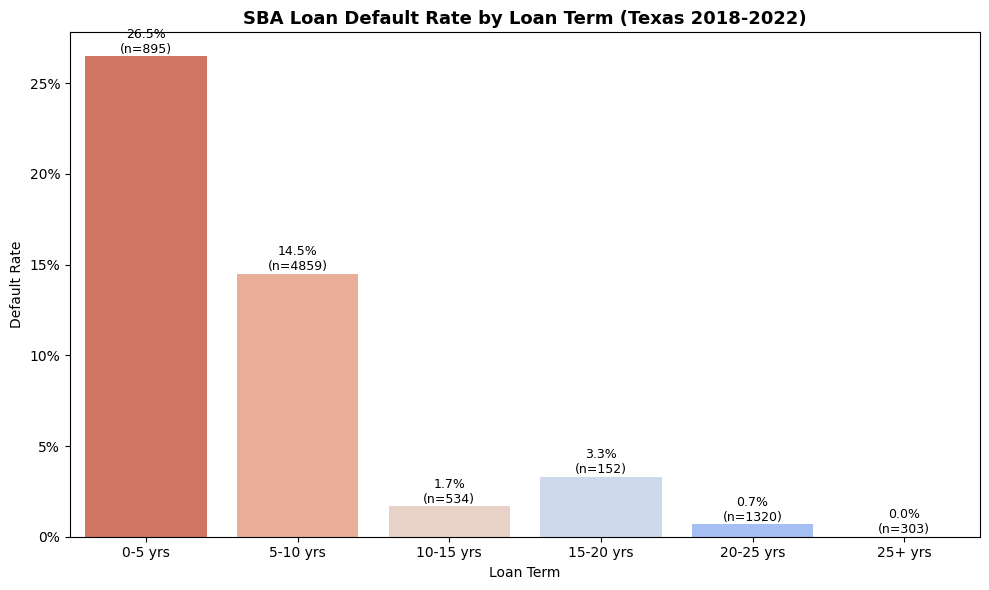

  term_category  total_loans  default_rate
0       0-5 yrs          895      0.264804
1      5-10 yrs         4859      0.144886
2     10-15 yrs          534      0.016854
3     15-20 yrs          152      0.032895
4     20-25 yrs         1320      0.006818
5       25+ yrs          303      0.000000


In [15]:
# ============================================
# Cell 11: Default Rate by Loan Term
# Answers: Do shorter term loans default more?
# ============================================

# Bin term months into categories
model_df['term_category'] = pd.cut(model_df['terminmonths'],
                                    bins=[0, 60, 120, 180, 240, 300, 999],
                                    labels=['0-5 yrs', '5-10 yrs', '10-15 yrs',
                                            '15-20 yrs', '20-25 yrs', '25+ yrs'])

term_default = (model_df.groupby('term_category', observed=True)
                .agg(total_loans=('defaulted', 'count'),
                     default_rate=('defaulted', 'mean'))
                .reset_index())

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=term_default, x='term_category', y='default_rate',
            palette='coolwarm_r', ax=ax)

for i, (rate, total) in enumerate(zip(term_default['default_rate'],
                                       term_default['total_loans'])):
    ax.text(i, rate + 0.002, f'{rate*100:.1f}%\n(n={total})',
            ha='center', fontsize=9)

ax.set_title('SBA Loan Default Rate by Loan Term (Texas 2018-2022)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Loan Term')
ax.set_ylabel('Default Rate')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/rgv_business_survival/charts/10_default_by_term.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(term_default)

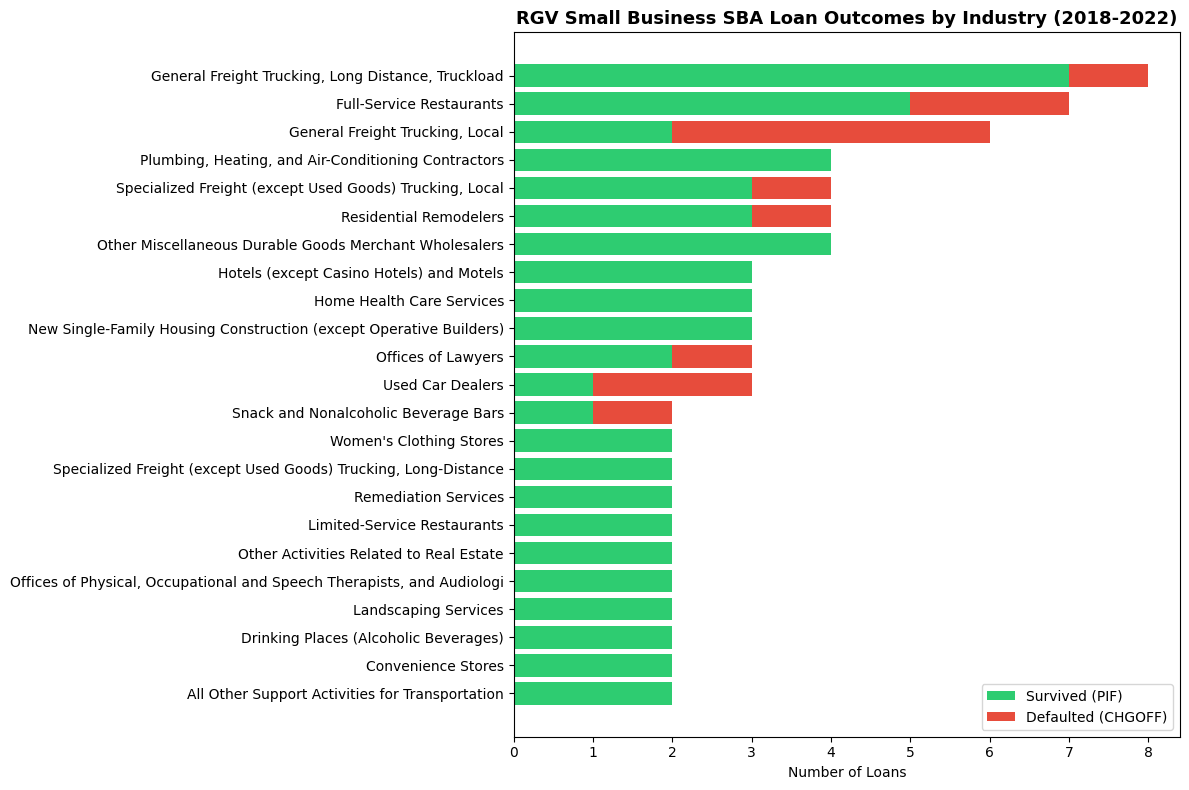

In [16]:
# ============================================
# Cell 12: RGV Industries — Surviving vs Defaulting
# Answers: Which RGV industries thrive vs fail?
# ============================================

rgv_only = model_df[model_df['borrzip'].astype(str).str.startswith('785')]

rgv_industry_detail = (rgv_only.groupby('naicsdescription')
                        .agg(total_loans=('defaulted', 'count'),
                             survived=('defaulted', lambda x: (x==0).sum()),
                             defaulted=('defaulted', lambda x: (x==1).sum()))
                        .reset_index()
                        .query('total_loans >= 2')
                        .sort_values('total_loans', ascending=True))

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(rgv_industry_detail['naicsdescription'],
        rgv_industry_detail['survived'],
        color='#2ecc71', label='Survived (PIF)')
ax.barh(rgv_industry_detail['naicsdescription'],
        rgv_industry_detail['defaulted'],
        left=rgv_industry_detail['survived'],
        color='#e74c3c', label='Defaulted (CHGOFF)')

ax.set_title('RGV Small Business SBA Loan Outcomes by Industry (2018-2022)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Loans')
ax.set_ylabel('')
ax.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/rgv_business_survival/charts/11_rgv_survived_vs_defaulted.png',
            dpi=150, bbox_inches='tight')
plt.show()